In [2]:
import os
import sys
from pathlib import Path
import importlib
import torch

In [3]:
#@title Mount Goole Drive

root_path = "/content/drive/MyDrive/MSc/Flood-Mapping"  #@param {type:"string", multiline:true}


mount_drive = True  #@param {type:"boolean"}

clone_repo = False  #@param {type:"boolean"}

if clone_repo and mount_drive:

    from google.colab import drive
    drive.mount("/content/drive")

    root_path = os.path.join(root_path, "Flood-Mapping")

    !git clone https://github.com/TAX2310/Flood-Mapping.git $root_path

    sys.path.append(os.path.join(root_path))

    from src.config import Fusion_CFG
    cfg = Fusion_CFG()

    cfg.ROOT = Path(root_path)

elif not clone_repo and mount_drive:
    from google.colab import drive
    drive.mount("/content/drive")

    sys.path.append(os.path.join(root_path))

    from src.config import Fusion_CFG
    cfg = Fusion_CFG()

    cfg.ROOT = Path(root_path)

elif clone_repo and not mount_drive:
    root_path = "Flood-Mapping"

    !git clone https://github.com/TAX2310/Flood-Mapping.git

    sys.path.append(root_path)

    from src.config import Fusion_CFG
    cfg = Fusion_CFG()

    cfg.ROOT = Path(root_path)

else:
    from src.config import Fusion_CFG
    cfg = Fusion_CFG()

    sys.path.append(os.path.join(cfg.ROOT))

cfg.DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

Mounted at /content/drive


In [4]:
requirements = cfg.ROOT / "requirements.txt"
!pip install -r {requirements}

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 9.9 MB/s eta 0:00:00


In [5]:
import src.train.training as training
import src.test.testing as testing
import src.util.io as io
import src.util.plotting as plot

In [ ]:
learning_rates = [1e-3, 1e-4]
batch_sizes = [32, 64]
weight_decays = [0.0, 1e-5]
dropout_rates = [0.0, 0.2]

num_workers = 8

In [ ]:
for learning_rate in learning_rates:
    for batch_size in batch_sizes:
        for weight_decay in weight_decays:
            for dropout_rate in dropout_rates:
                cfg.LR = learning_rate
                cfg.BATCH_SIZE = batch_size
                cfg.WEIGHT_DECAY = weight_decay
                cfg.DROPOUT_RATE = dropout_rate
                training.train_from_file(cfg, num_workers=num_workers)

Found 16 model subdirectories in /content/drive/MyDrive/MSc/Flood-Mapping/experiments/STURM-fusion-24/Fusion_SAR_Optical


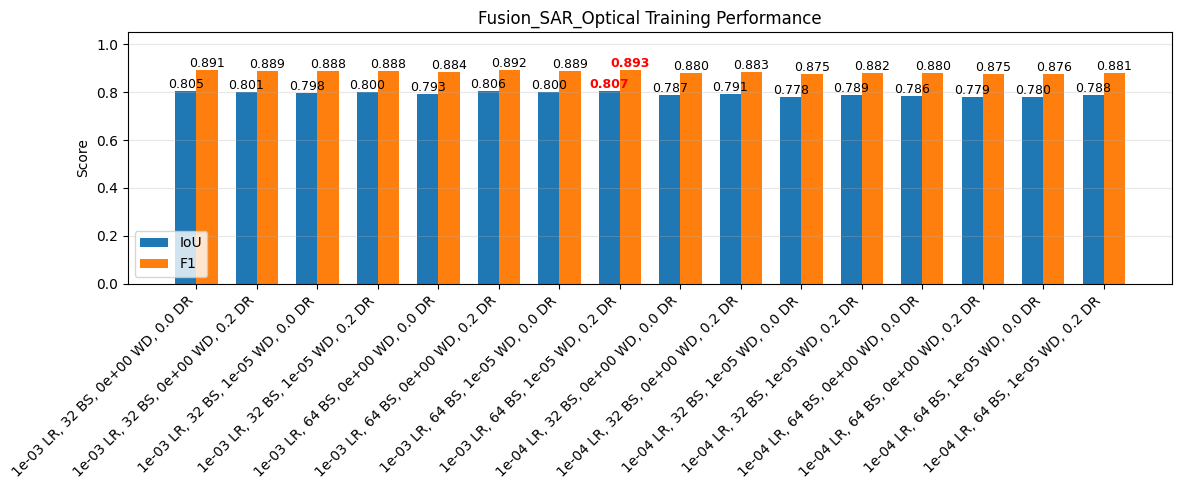

In [5]:
plot.view_f1_iou_bar(cfg)

In [12]:
plot.view_training_metrics(cfg)

Dropdown(description='Model:', layout=Layout(width='700px'), options=(PosixPath('/content/drive/MyDrive/MSc/Fl…

Button(description='Plot metrics', style=ButtonStyle())

Output()

In [6]:
import src.inference.inference as inference

samples = ["EMSR470_AOI01_46_07_2_1.tif",
           "EMSR441_AOI05_2_3_2_2.tif",
           "EMSR570_AOI02_07_03_2_1.tif"
]


results = inference.inference(cfg, cfg.FUSION_MODEL, samples)
all_results = inference.inference(cfg, cfg.FUSION_MODEL)
io.create_test_results_csv(cfg, all_results, cfg.METADATA_CSV, cfg.FUSION_TEST_RESULTS_CSV)

Model directory: /content/drive/MyDrive/MSc/Flood-Mapping/experiments/STURM-fusion-24/Fusion_SAR_Optical/lr_0.001/bs_64/wd_1e-05/dr_0.2


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Model directory: /content/drive/MyDrive/MSc/Flood-Mapping/experiments/STURM-fusion-24/Fusion_SAR_Optical/lr_0.001/bs_64/wd_1e-05/dr_0.2


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


,Unnamed: 0,ems_code,aoi_code,floodmap_id,event_type,country,tile_id,floodmap_date,sentinel2_timestamp,sentinel1_timestamp,...,accuracy,precision,recall,f1,iou,flood_pixels,non_flood_pixels,ignored_pixels,total_valid_pixels,flood_pixel_percentage
0,1212,EMSR470,AOI01,EMSR470_AOI01_DEL_PRODUCT,Flash flood,Togo,EMSR470_AOI01_14_25_2_2.tif,2020-10-14 20:11:00,2020-10-13 10:19:09,14/10/2020 18:11,...,0.980225,0.755474,0.936652,0.836364,0.718750,884,15500,0,16384,0.053955
1,2673,EMSR629,AOI02,EMSR629_AOI02_DEL_PRODUCT,Riverine flood,Pakistan,EMSR629_AOI02_01_13_2_1.tif,2022-08-30 07:45:00,2022-08-31 05:56:51,30/08/2022 01:25,...,0.837463,0.971608,0.655045,0.782523,0.642742,7314,9070,0,16384,0.446411
2,2630,EMSR570,AOI02,EMSR570_AOI02_DEL_MONIT01,Riverine flood,Australia,EMSR570_AOI02_07_03_2_1.tif,2022-03-31 08:44:00,2022-03-31 23:52:39,31/03/2022 19:14,...,0.835266,0.896299,0.759757,0.822399,0.698368,8225,8159,0,16384,0.502014
3,1932,EMSR479,AOI02,EMSR479_AOI02_DEL_PRODUCT,Flash flood,Mexico,EMSR479_AOI02_27_22_2_2.tif,2020-11-08 17:35:00,2020-11-08 16:35:11,09/11/2020 12:01,...,0.940735,0.967118,0.947008,0.956957,0.917467,11398,4986,0,16384,0.695679
4,2202,EMSR479,AOI02,EMSR479_AOI02_DEL_PRODUCT,Flash flood,Mexico,EMSR479_AOI02_43_51_1_1.tif,2020-11-08 17:35:00,2020-11-08 16:35:11,09/11/2020 12:02,...,0.982910,0.482143,0.097122,0.161677,0.087948,278,16106,0,16384,0.016968
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,1174,EMSR470,AOI01,EMSR470_AOI01_DEL_PRODUCT,Flash flood,Togo,EMSR470_AOI01_11_25_1_2.tif,2020-10-14 20:11:00,2020-10-13 10:19:09,14/10/2020 18:11,...,0.893250,0.429550,1.000000,0.600958,0.429550,1317,15067,0,16384,0.080383
194,2138,EMSR479,AOI02,EMSR479_AOI02_DEL_PRODUCT,Flash flood,Mexico,EMSR479_AOI02_34_40_2_2.tif,2020-11-08 17:35:00,2020-11-08 16:35:11,09/11/2020 12:01,...,0.979309,0.864851,0.960246,0.910056,0.834956,1786,14598,0,16384,0.109009
195,67,EMSR279,05ZARAGOZA,EMSR279_05ZARAGOZA_DEL_v2,Riverine flood,Spain,EMSR279_05ZARAGOZA_08_12_1_1.tif,2018-04-13 19:52:00,2018-04-14 10:56:51,13/04/2018 17:54,...,0.915710,0.971474,0.893077,0.930627,0.870256,10372,6012,0,16384,0.633057
196,508,EMSR407,AOI01,EMSR407_AOI01_DEL_PRODUCT,Flash flood,United Kingdom,EMSR407_AOI01_12_16_2_1.tif,2019-11-14 19:02:00,2019-11-13 11:12:19,14/11/2019 06:14,...,0.952148,0.716216,0.125000,0.212851,0.119101,848,15536,0,16384,0.051758


id: torch.Size([1])
sample_id: EMSR441_AOI05_2_3_2_2.tif
s1_image: torch.Size([1, 2, 128, 128])
s2_image: torch.Size([1, 9, 128, 128])
mask: torch.Size([1, 1, 128, 128])
prob: torch.Size([128, 128])
pred: torch.Size([128, 128])
reference_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/S2/EMSR441_AOI05_2_3_2_2.tif
mask_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/floodmaps/EMSR441_AOI05_2_3_2_2.tif
accuracy: 0.98016357421875
precision: 0.0
recall: 0.0
f1: 0.0
iou: 0.0


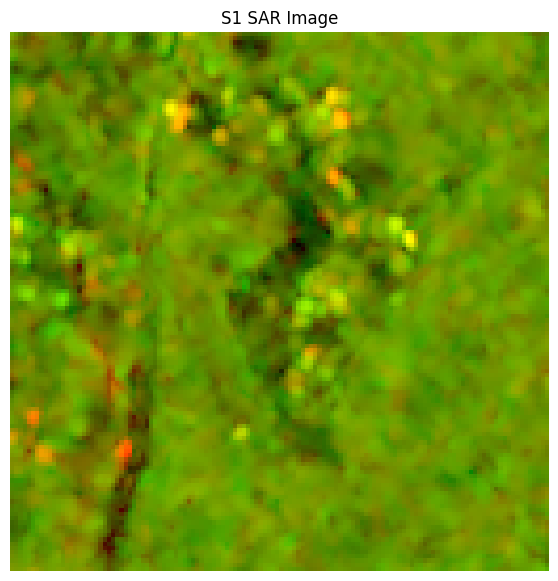

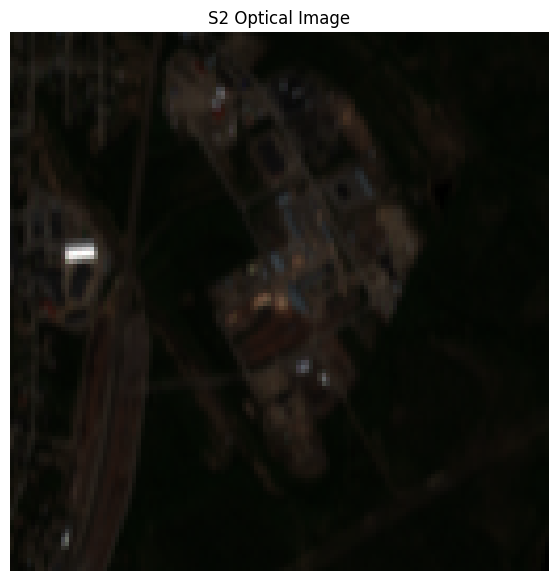

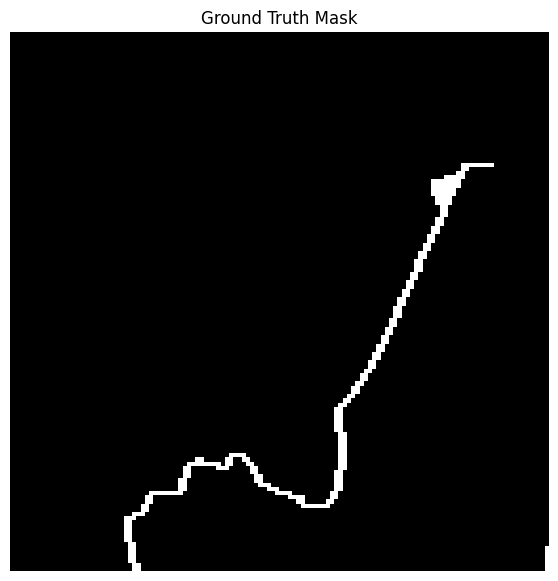

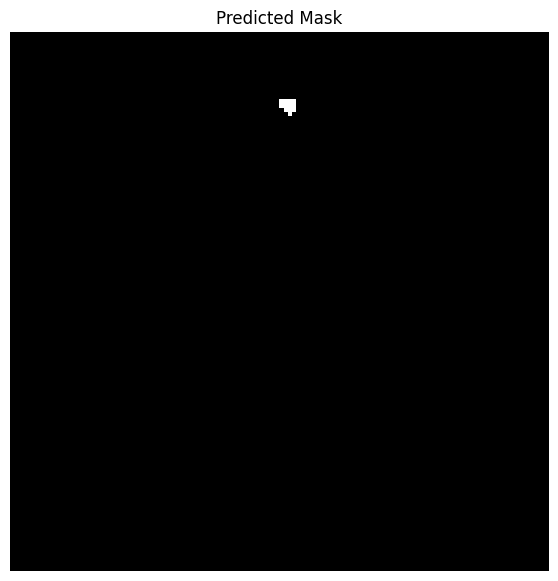

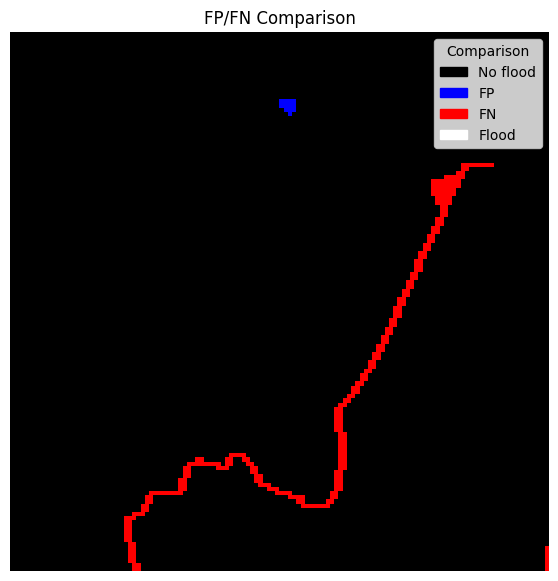

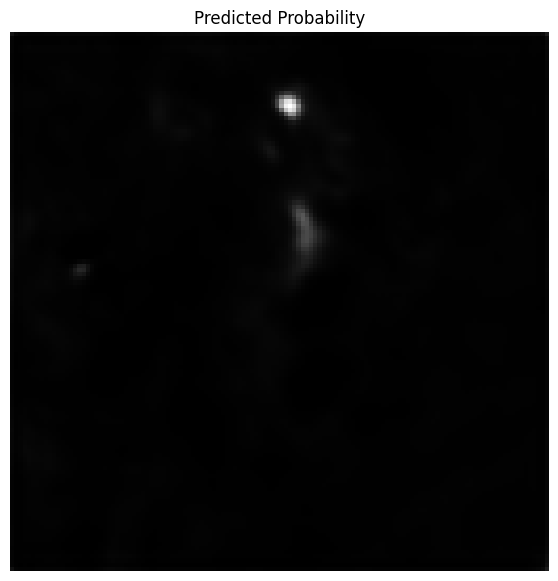

id: torch.Size([1])
sample_id: EMSR470_AOI01_46_07_2_1.tif
s1_image: torch.Size([1, 2, 128, 128])
s2_image: torch.Size([1, 9, 128, 128])
mask: torch.Size([1, 1, 128, 128])
prob: torch.Size([128, 128])
pred: torch.Size([128, 128])
reference_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/S2/EMSR470_AOI01_46_07_2_1.tif
mask_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/floodmaps/EMSR470_AOI01_46_07_2_1.tif
accuracy: 0.99053955078125
precision: 0.9757799506187439
recall: 0.992277204990387
f1: 0.9839593768119812
iou: 0.9684253334999084


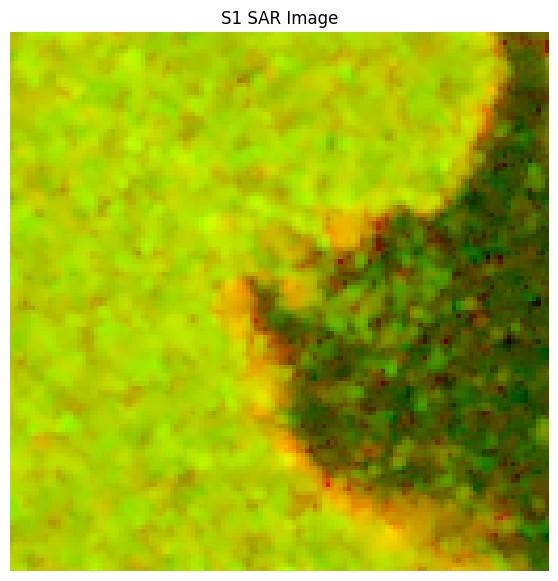

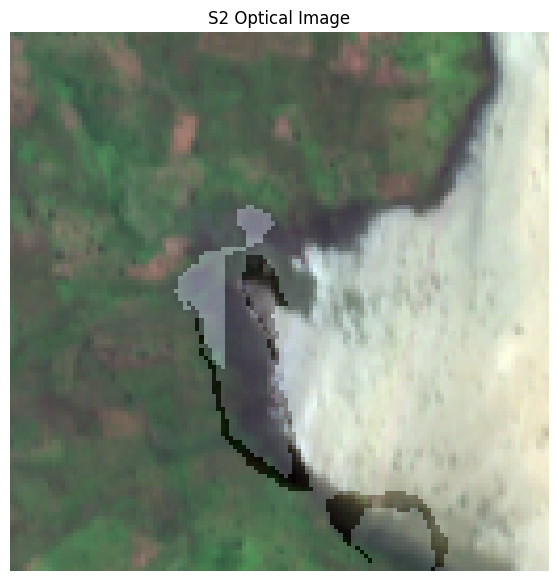

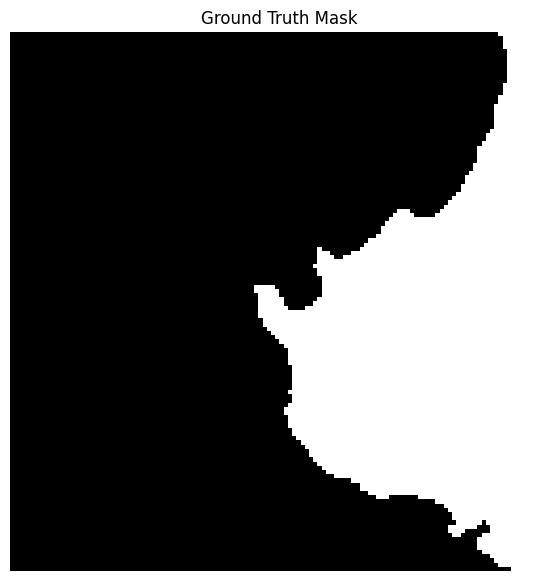

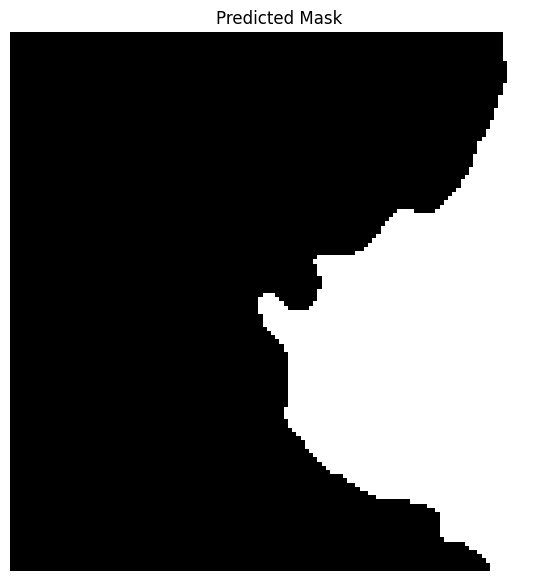

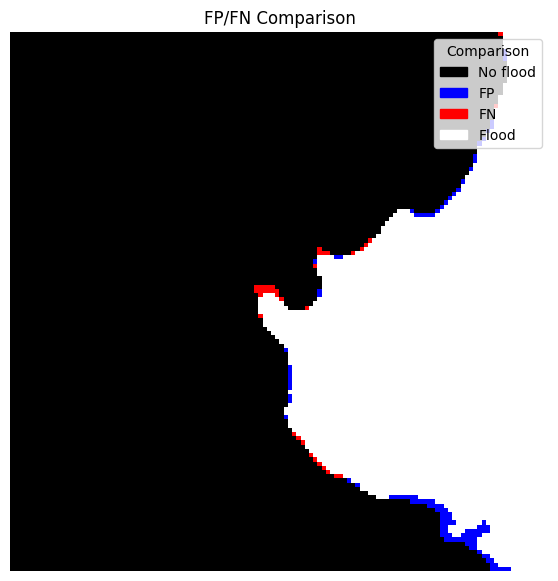

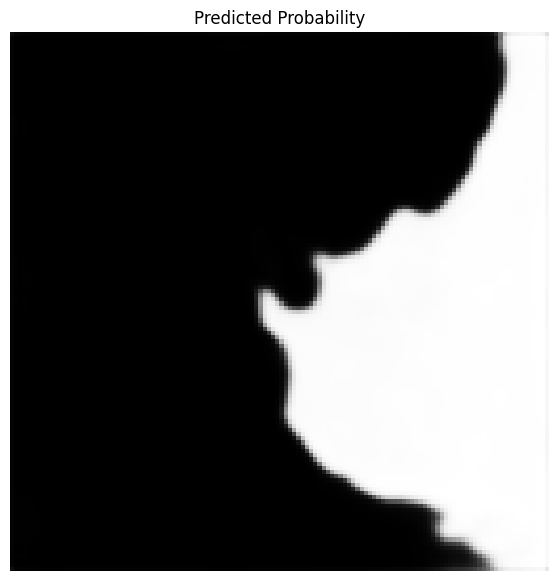

id: torch.Size([1])
sample_id: EMSR570_AOI02_07_03_2_1.tif
s1_image: torch.Size([1, 2, 128, 128])
s2_image: torch.Size([1, 9, 128, 128])
mask: torch.Size([1, 1, 128, 128])
prob: torch.Size([128, 128])
pred: torch.Size([128, 128])
reference_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/S2/EMSR570_AOI02_07_03_2_1.tif
mask_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/floodmaps/EMSR570_AOI02_07_03_2_1.tif
accuracy: 0.83526611328125
precision: 0.8962994813919067
recall: 0.759756863117218
f1: 0.8223990201950073
iou: 0.6983683705329895


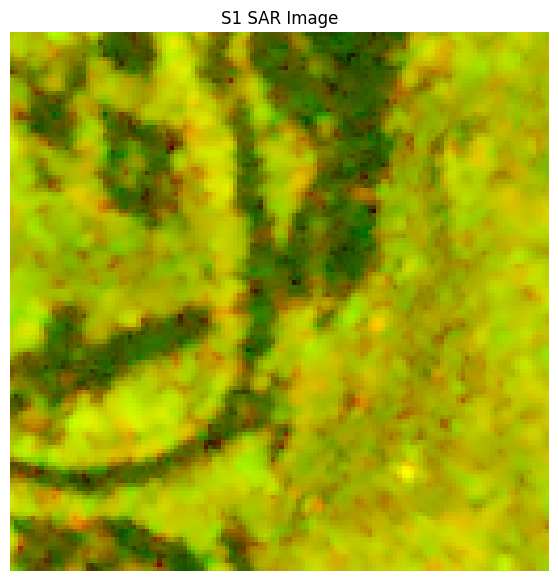

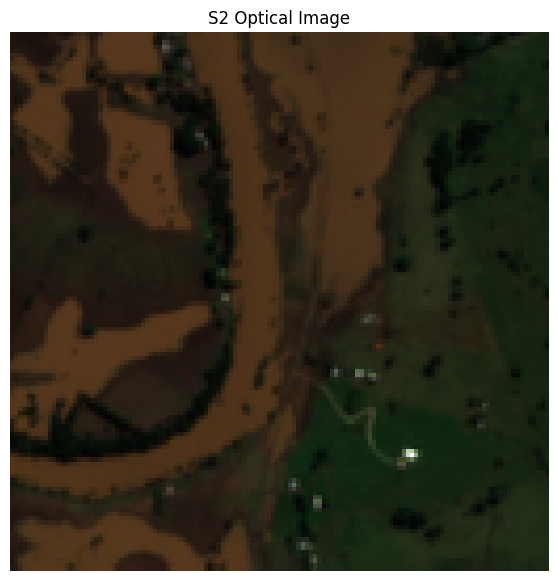

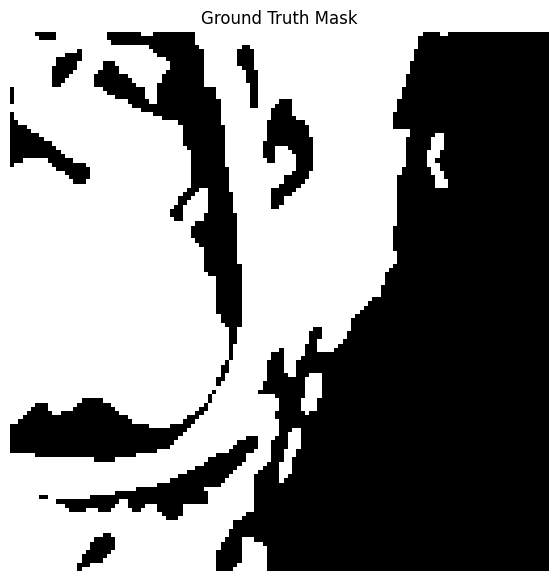

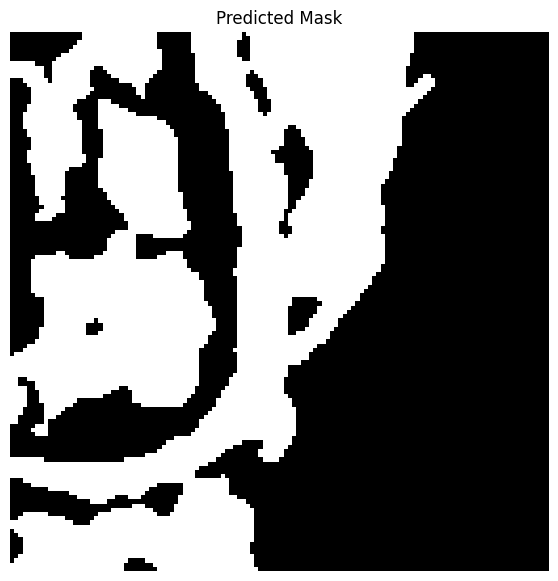

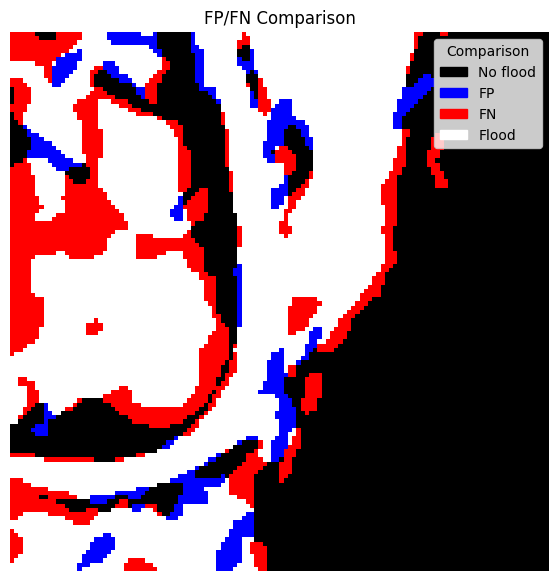

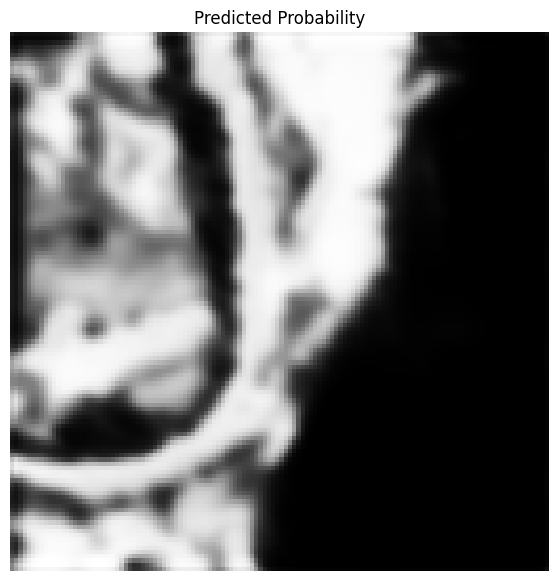

In [ ]:
plot.plot_fusion_results(results)

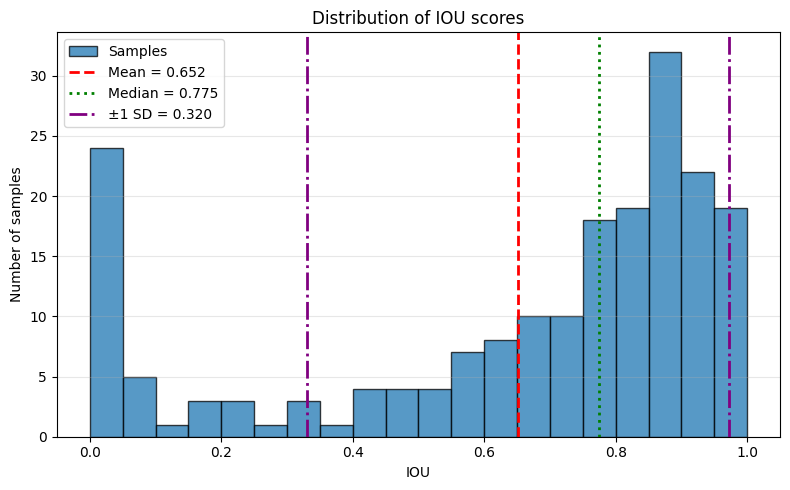

In [7]:
plot.plot_metric_distribution_from_csv(cfg.FUSION_TEST_RESULTS_CSV)

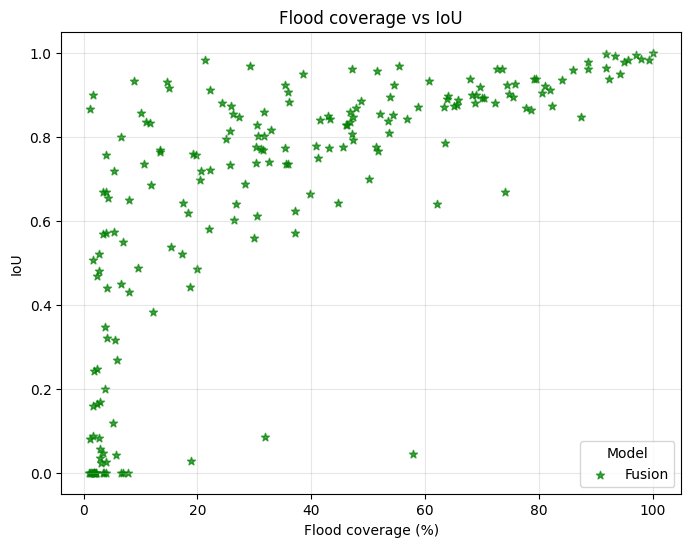

In [8]:
plot.plot_iou_vs_flood_scatter([cfg.FUSION_TEST_RESULTS_CSV])

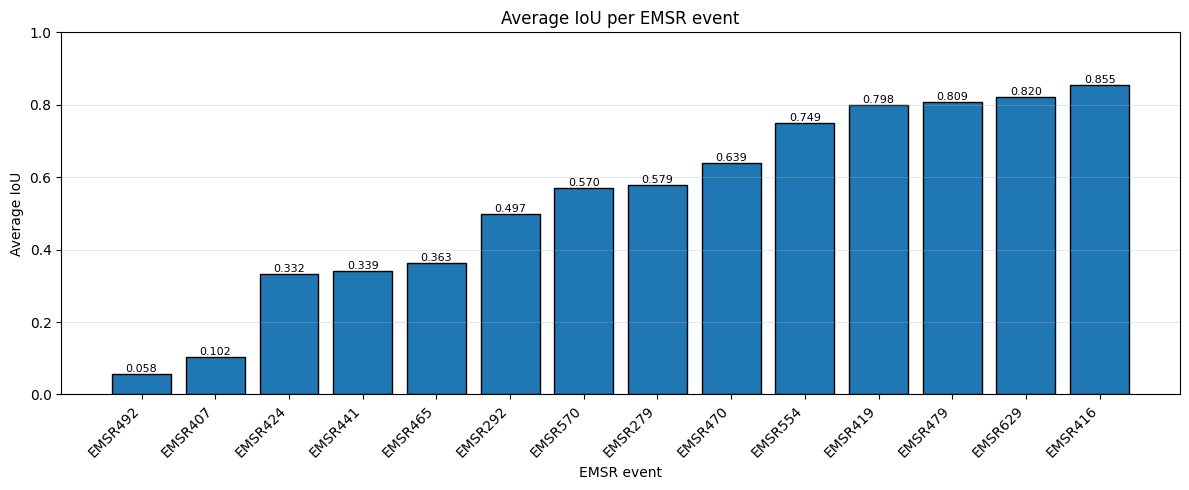

,event_id,mean_iou
10,EMSR492,0.057540
2,EMSR407,0.102070
5,EMSR424,0.332136
6,EMSR441,0.339485
7,EMSR465,0.362602
1,EMSR292,0.496984
12,EMSR570,0.569971
0,EMSR279,0.578705
8,EMSR470,0.638576
11,EMSR554,0.749215


In [9]:
plot.plot_average_iou_per_event(cfg.FUSION_TEST_RESULTS_CSV)

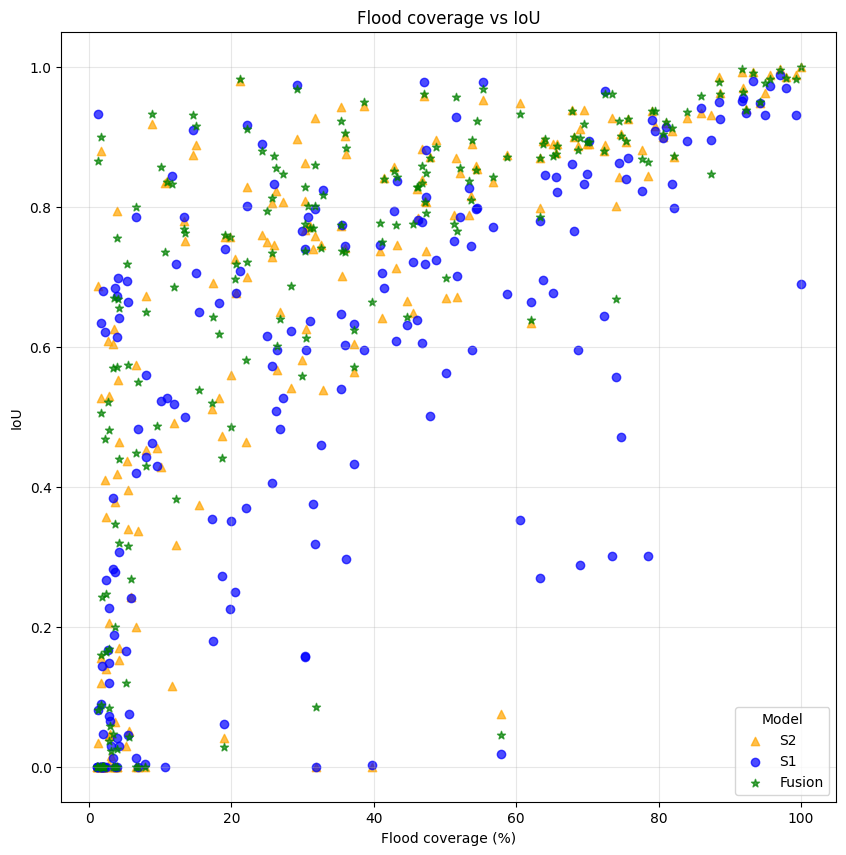

In [10]:
plot.plot_iou_vs_flood_scatter([cfg.S2_TEST_RESULTS_CSV,
                                cfg.S1_TEST_RESULTS_CSV,
                                cfg.FUSION_TEST_RESULTS_CSV], figsize=(10, 10))

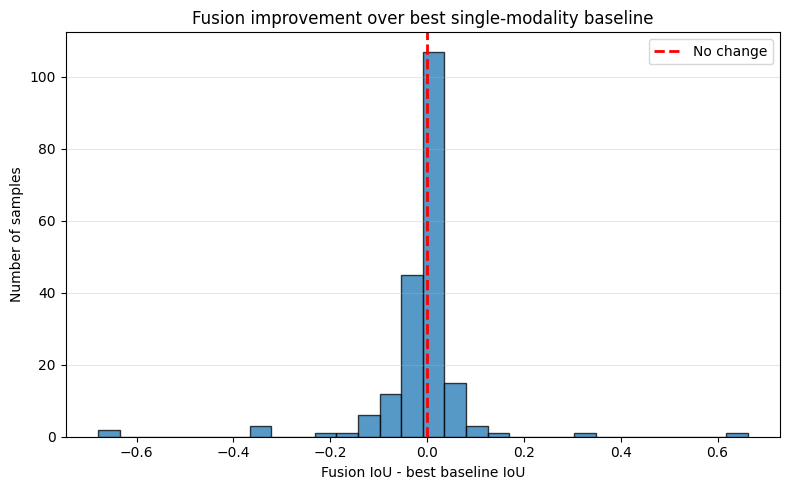

,tile_id,fusion_iou,s1_iou,s2_iou,best_baseline_iou,fusion_minus_best_baseline
0,EMSR470_AOI01_14_25_2_2.tif,0.718750,0.693878,0.436588,0.693878,0.024872
1,EMSR629_AOI02_01_13_2_1.tif,0.642742,0.631037,0.664903,0.664903,-0.022161
2,EMSR570_AOI02_07_03_2_1.tif,0.698368,0.561944,0.669262,0.669262,0.029107
3,EMSR479_AOI02_27_22_2_2.tif,0.917467,0.832146,0.938585,0.938585,-0.021118
4,EMSR479_AOI02_43_51_1_1.tif,0.087948,0.000000,0.155488,0.155488,-0.067540
...,...,...,...,...,...,...
193,EMSR470_AOI01_11_25_1_2.tif,0.429550,0.559949,0.452689,0.559949,-0.130399
194,EMSR479_AOI02_34_40_2_2.tif,0.834956,0.526063,0.837106,0.837106,-0.002150
195,EMSR279_05ZARAGOZA_08_12_1_1.tif,0.870256,0.269082,0.869372,0.869372,0.000883
196,EMSR407_AOI01_12_16_2_1.tif,0.119101,0.165758,0.029446,0.165758,-0.046657


In [11]:
plot.plot_fusion_improvement_distribution([cfg.S2_TEST_RESULTS_CSV,
                                cfg.S1_TEST_RESULTS_CSV,
                                cfg.FUSION_TEST_RESULTS_CSV])

In [12]:
plot.plot_fusion_results(all_results)

Output hidden; open in https://colab.research.google.com to view.

In [6]:
import src.inference.inference as inference

samples = ["EMSR407_AOI01_03_17_2_1.tif",
           "EMSR470_AOI01_29_13_2_2.tif",
           "EMSR470_AOI01_10_25_1_1.tif",
           "EMSR470_AOI01_47_10_1_2.tif",
           "EMSR629_AOI01_08_02_1_1.tif",
           "EMSR629_AOI01_09_01_1_2.tif"
]
# EMSR407_AOI01_03_17_2_1.tif posible cloud, EMSR470_AOI01_29_13_2_2.tif posible cloud, EMSR470_AOI01_10_25_1_1.tif high FN, EMSR470_AOI01_47_10_1_2.tif high FP, EMSR629_AOI01_08_02_1_1.tif  High % good success, EMSR629_AOI01_09_01_1_2.tif posible miss from threshold,
results = inference.inference(cfg, cfg.FUSION_MODEL, samples)

Model directory: /content/drive/MyDrive/MSc/Flood-Mapping/experiments/STURM-fusion-24/Fusion_SAR_Optical/lr_0.001/bs_64/wd_1e-05/dr_0.2


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


id: torch.Size([1])
sample_id: EMSR407_AOI01_03_17_2_1.tif
s1_image: torch.Size([1, 2, 128, 128])
s2_image: torch.Size([1, 9, 128, 128])
mask: torch.Size([1, 1, 128, 128])
prob: torch.Size([128, 128])
pred: torch.Size([128, 128])
reference_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/S2/EMSR407_AOI01_03_17_2_1.tif
mask_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/floodmaps/EMSR407_AOI01_03_17_2_1.tif
accuracy: 0.77056884765625
precision: 0.025408878922462463
recall: 0.1709233820438385
f1: 0.04424101486802101
iou: 0.022620905190706253


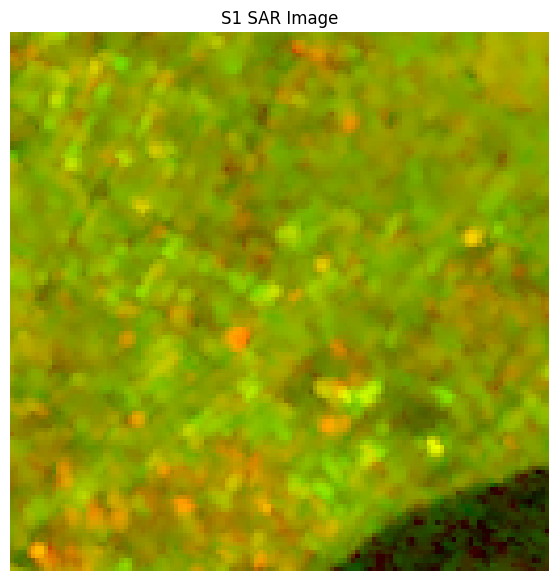

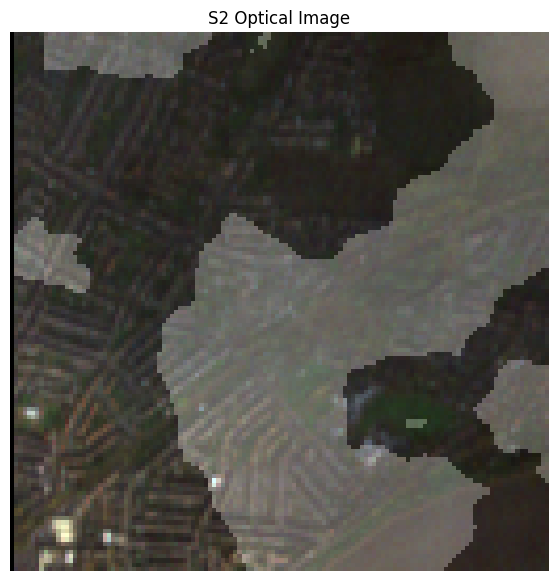

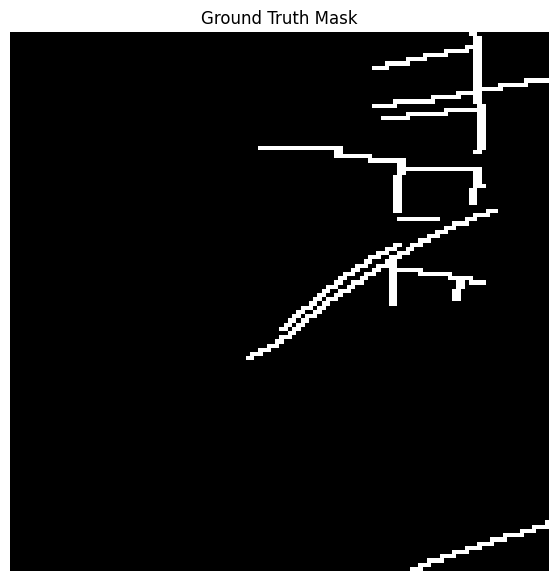

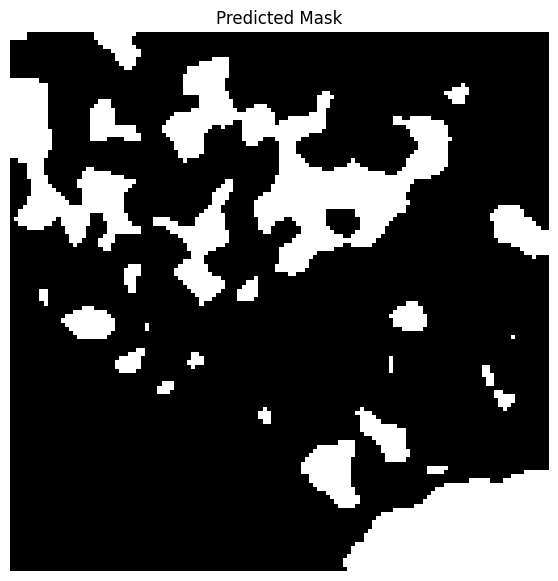

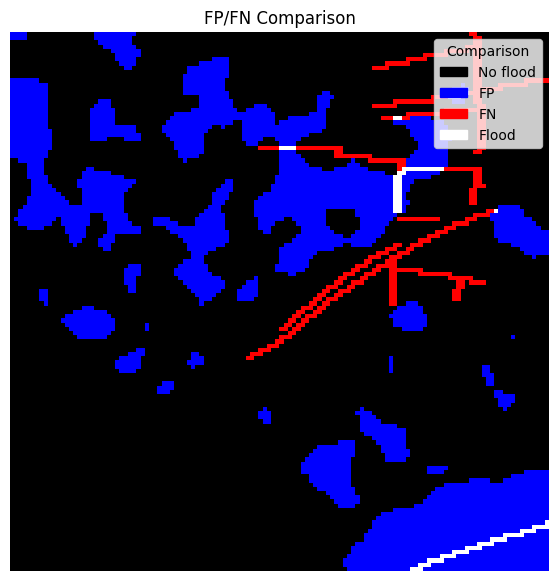

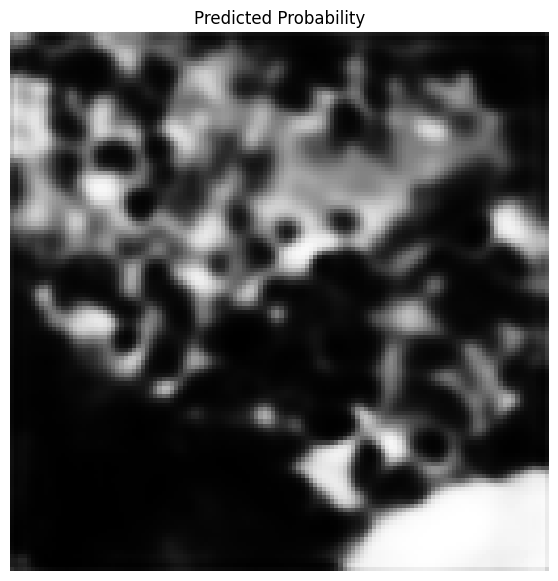

id: torch.Size([1])
sample_id: EMSR470_AOI01_10_25_1_1.tif
s1_image: torch.Size([1, 2, 128, 128])
s2_image: torch.Size([1, 9, 128, 128])
mask: torch.Size([1, 1, 128, 128])
prob: torch.Size([128, 128])
pred: torch.Size([128, 128])
reference_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/S2/EMSR470_AOI01_10_25_1_1.tif
mask_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/floodmaps/EMSR470_AOI01_10_25_1_1.tif
accuracy: 0.9002685546875
precision: 0.8649432063102722
recall: 0.7690654993057251
f1: 0.814191460609436
iou: 0.6866129636764526


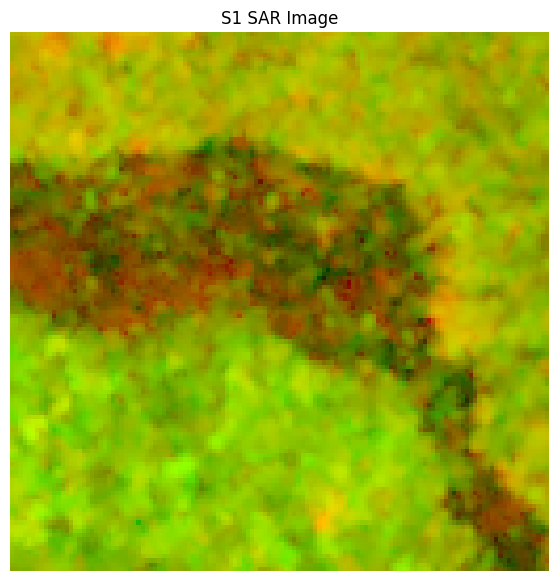

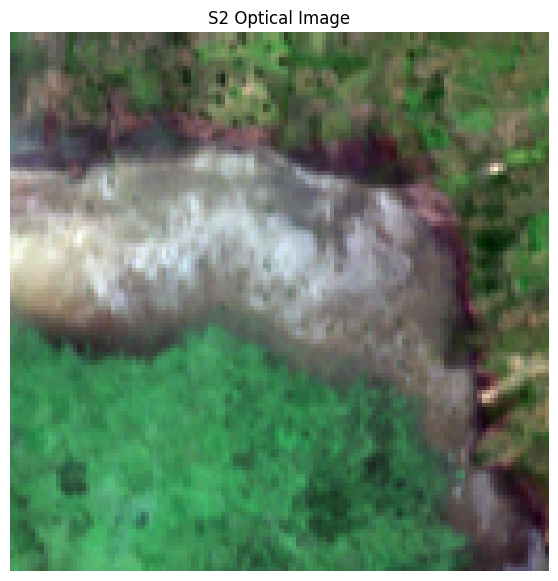

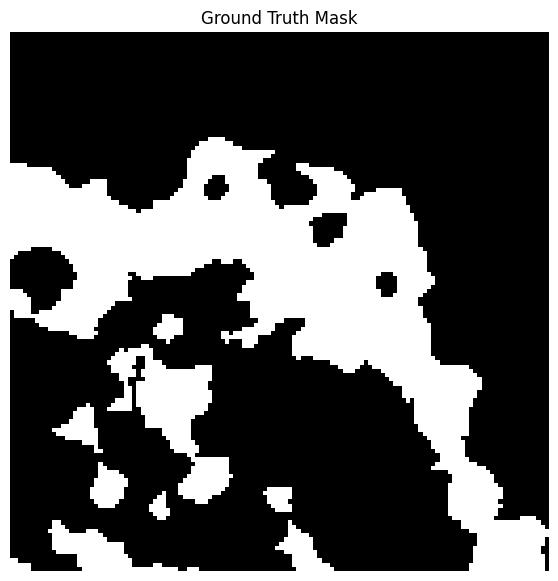

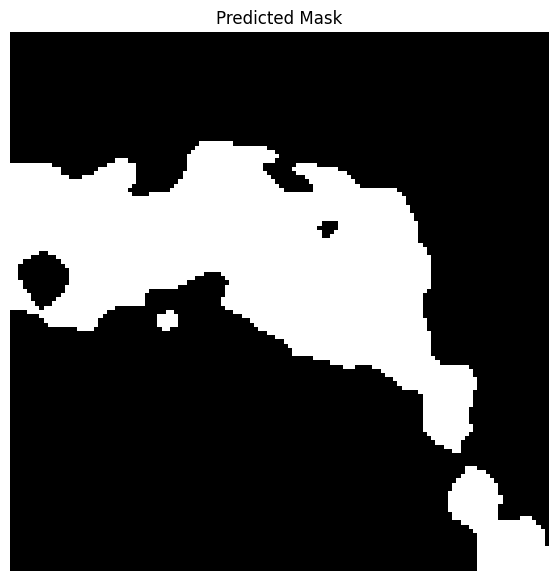

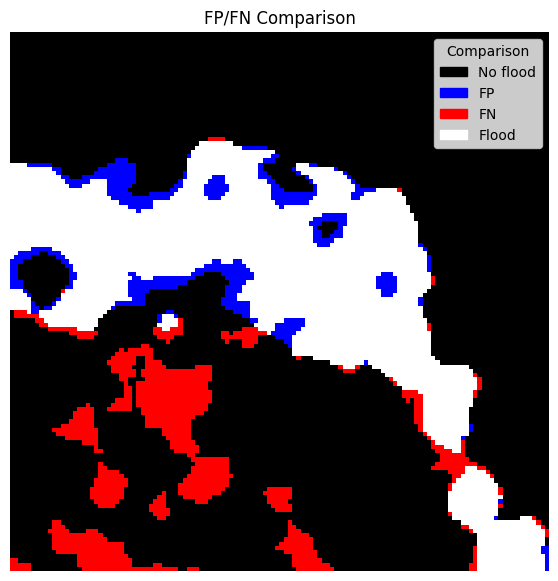

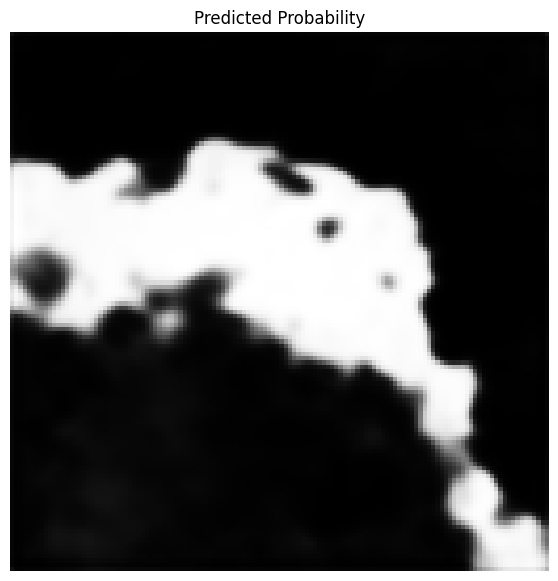

id: torch.Size([1])
sample_id: EMSR470_AOI01_29_13_2_2.tif
s1_image: torch.Size([1, 2, 128, 128])
s2_image: torch.Size([1, 9, 128, 128])
mask: torch.Size([1, 1, 128, 128])
prob: torch.Size([128, 128])
pred: torch.Size([128, 128])
reference_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/S2/EMSR470_AOI01_29_13_2_2.tif
mask_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/floodmaps/EMSR470_AOI01_29_13_2_2.tif
accuracy: 0.98199462890625
precision: 0.991817057132721
recall: 0.9755237102508545
f1: 0.9836028814315796
iou: 0.9677348732948303


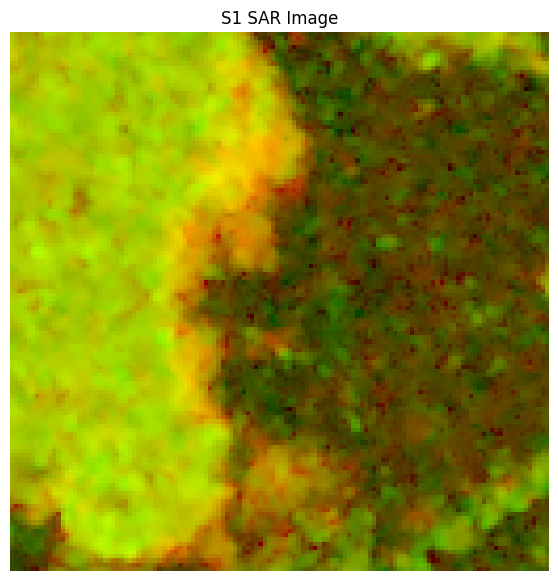

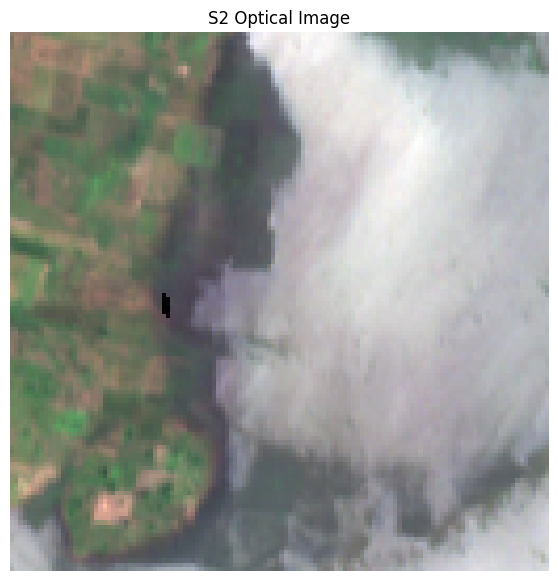

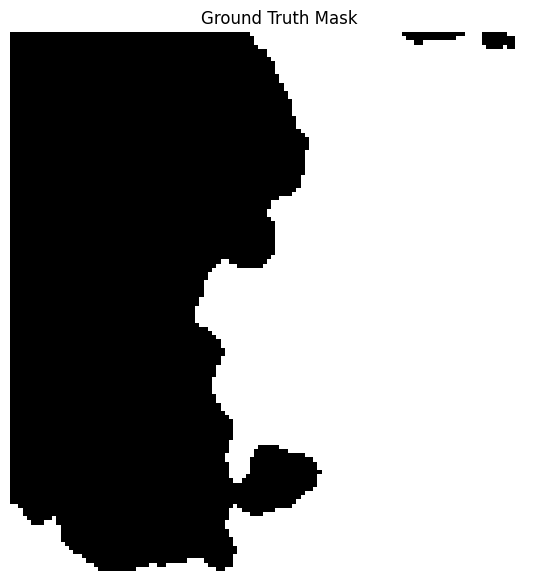

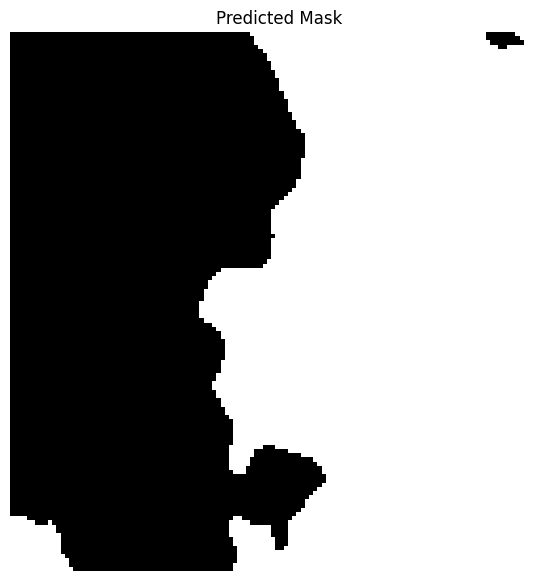

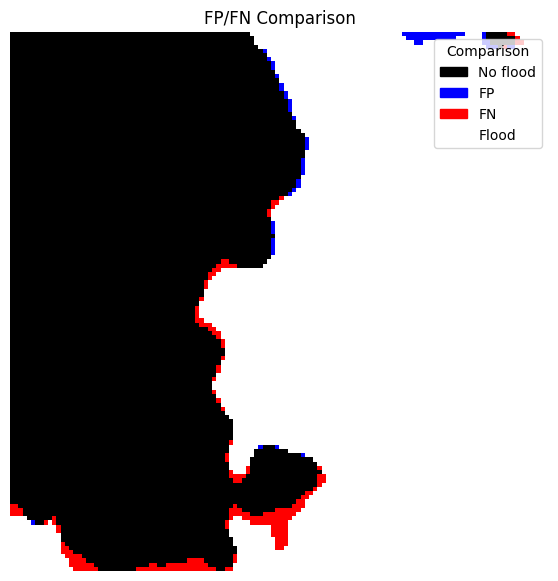

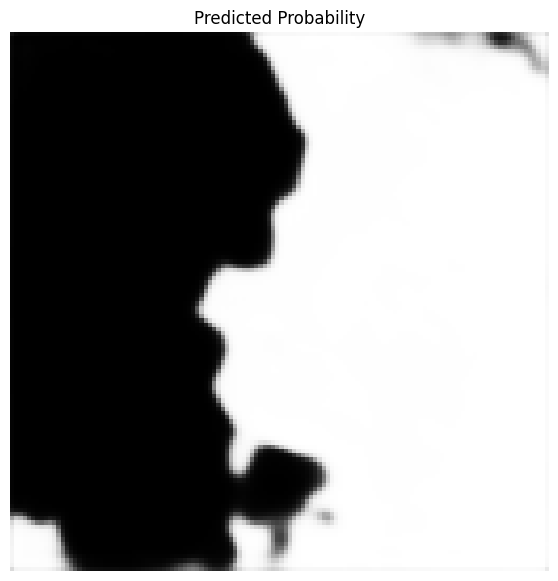

id: torch.Size([1])
sample_id: EMSR470_AOI01_47_10_1_2.tif
s1_image: torch.Size([1, 2, 128, 128])
s2_image: torch.Size([1, 9, 128, 128])
mask: torch.Size([1, 1, 128, 128])
prob: torch.Size([128, 128])
pred: torch.Size([128, 128])
reference_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/S2/EMSR470_AOI01_47_10_1_2.tif
mask_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/floodmaps/EMSR470_AOI01_47_10_1_2.tif
accuracy: 0.82733154296875
precision: 0.40467917919158936
recall: 0.8708873391151428
f1: 0.5525857210159302
iou: 0.3817744851112366


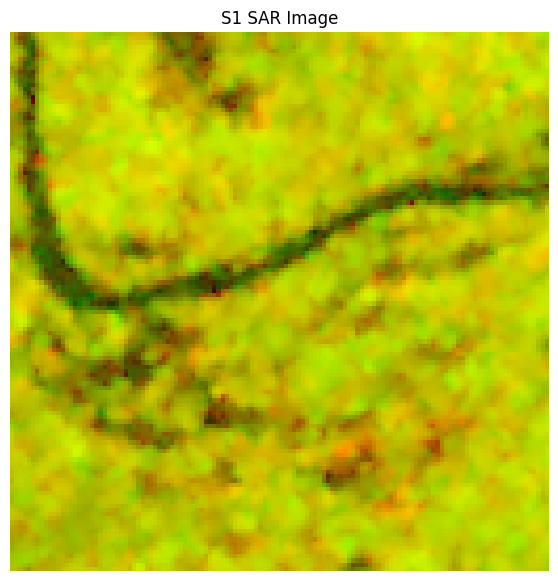

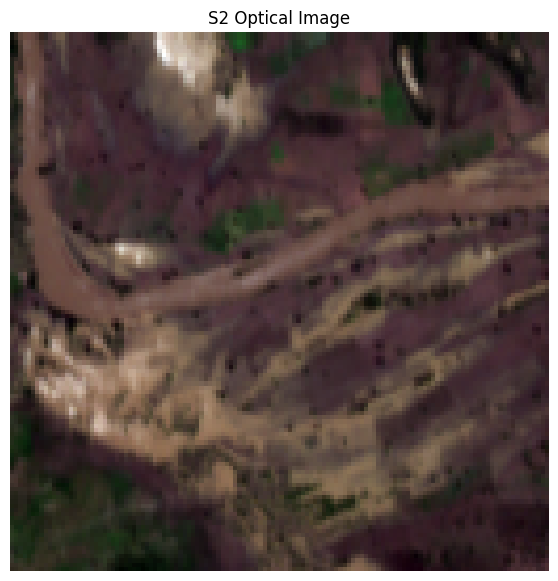

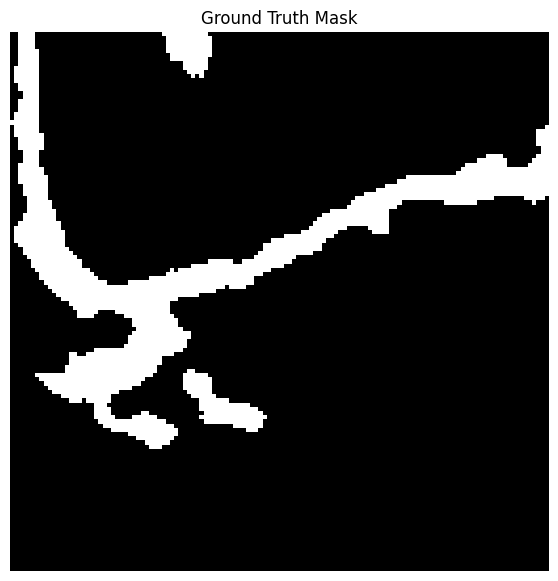

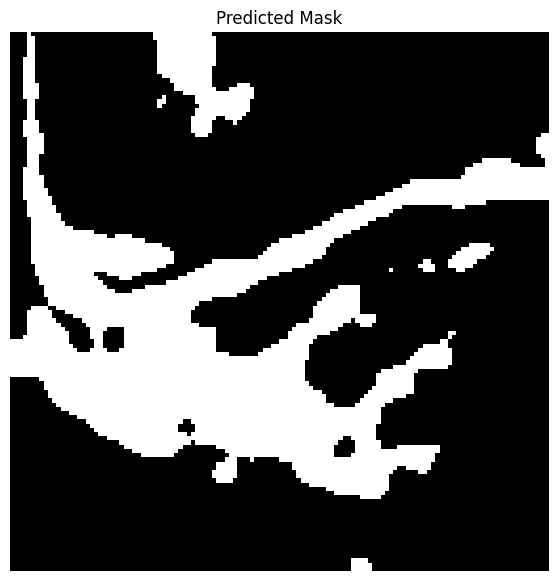

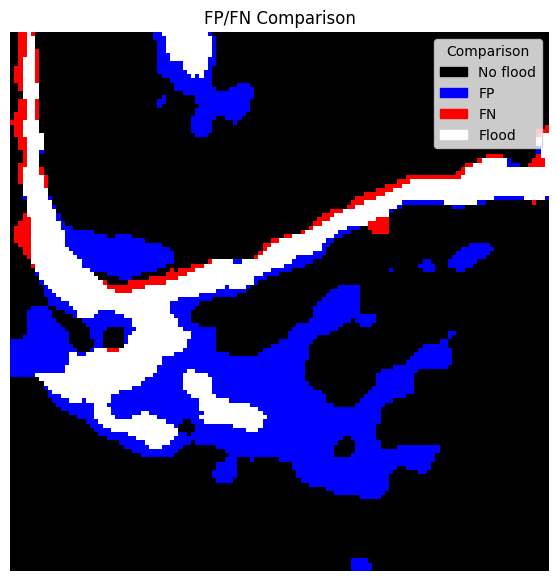

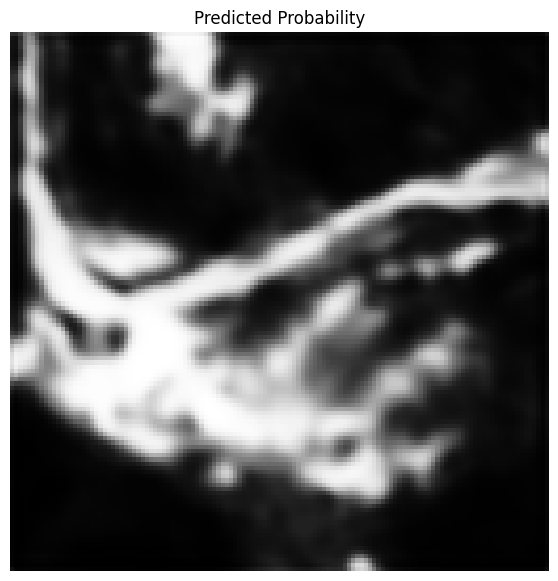

id: torch.Size([1])
sample_id: EMSR629_AOI01_08_02_1_1.tif
s1_image: torch.Size([1, 2, 128, 128])
s2_image: torch.Size([1, 9, 128, 128])
mask: torch.Size([1, 1, 128, 128])
prob: torch.Size([128, 128])
pred: torch.Size([128, 128])
reference_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/S2/EMSR629_AOI01_08_02_1_1.tif
mask_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/floodmaps/EMSR629_AOI01_08_02_1_1.tif
accuracy: 0.97784423828125
precision: 0.9910783767700195
recall: 0.985535204410553
f1: 0.9882990121841431
iou: 0.9768686890602112


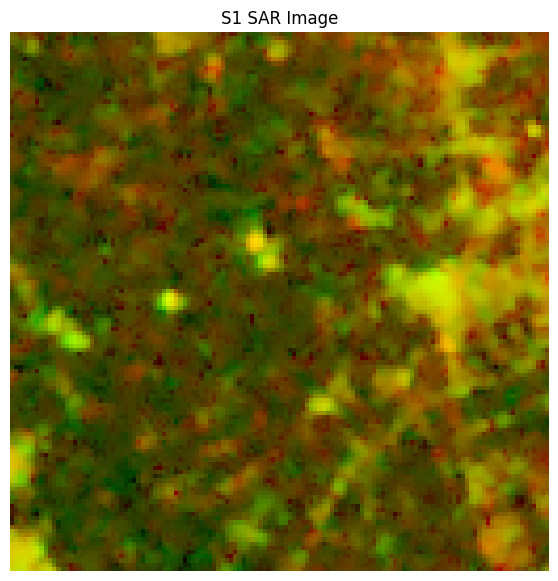

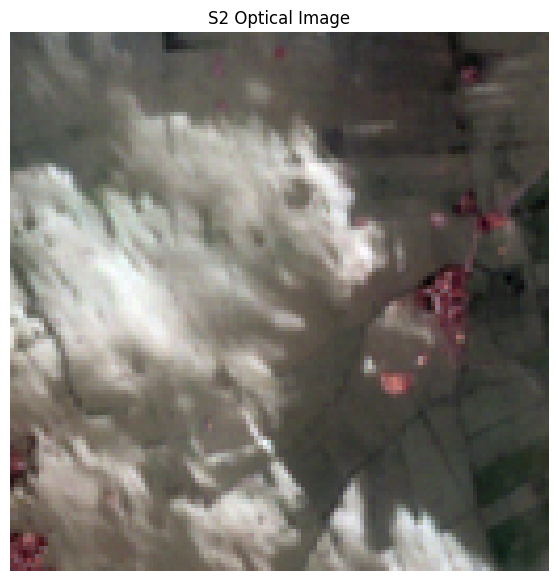

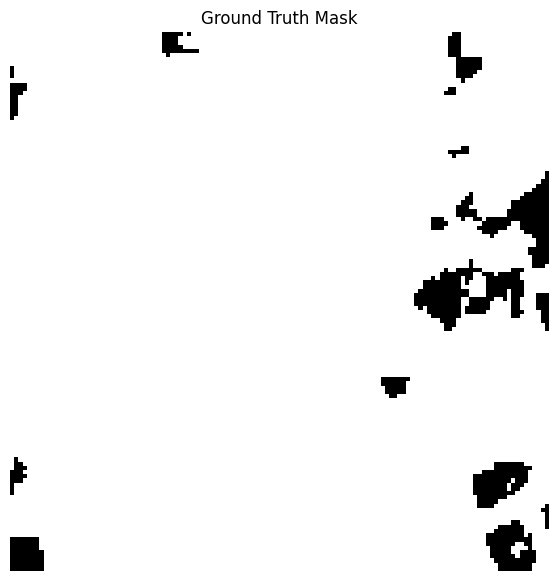

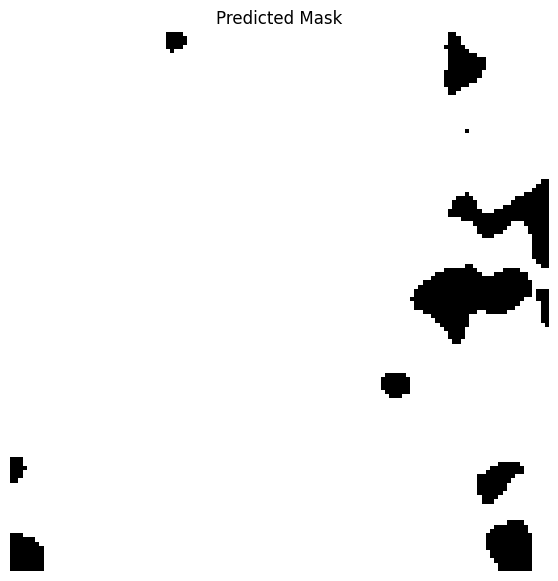

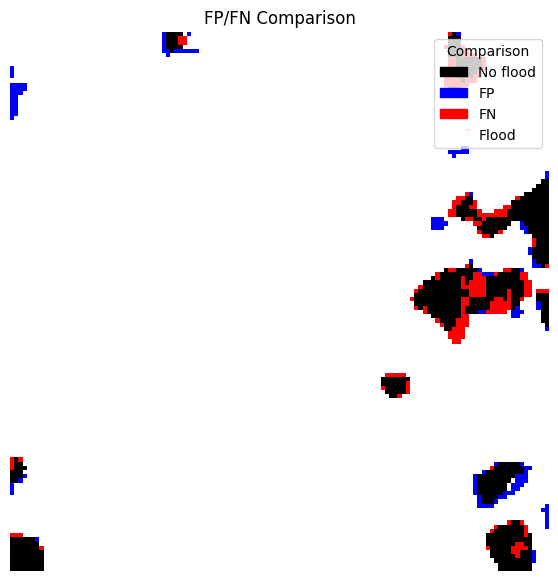

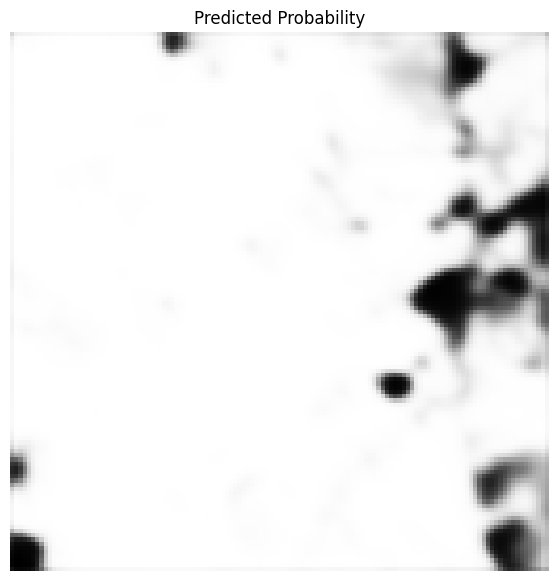

id: torch.Size([1])
sample_id: EMSR629_AOI01_09_01_1_2.tif
s1_image: torch.Size([1, 2, 128, 128])
s2_image: torch.Size([1, 9, 128, 128])
mask: torch.Size([1, 1, 128, 128])
prob: torch.Size([128, 128])
pred: torch.Size([128, 128])
reference_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/S2/EMSR629_AOI01_09_01_1_2.tif
mask_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/floodmaps/EMSR629_AOI01_09_01_1_2.tif
accuracy: 0.9847412109375
precision: 0.9911625385284424
recall: 0.9932643175125122
f1: 0.9922122955322266
iou: 0.9845449924468994


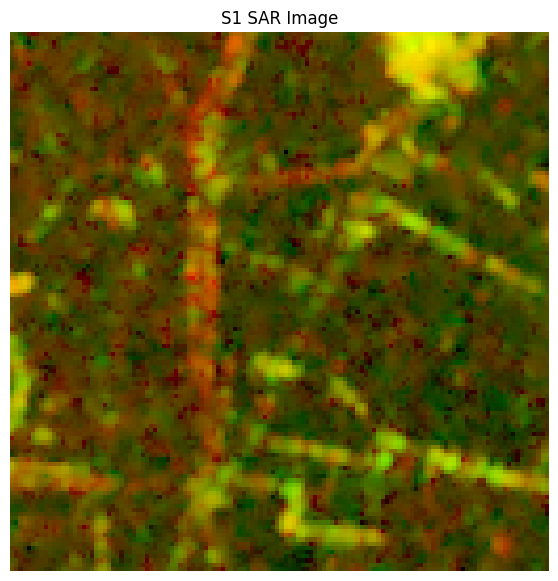

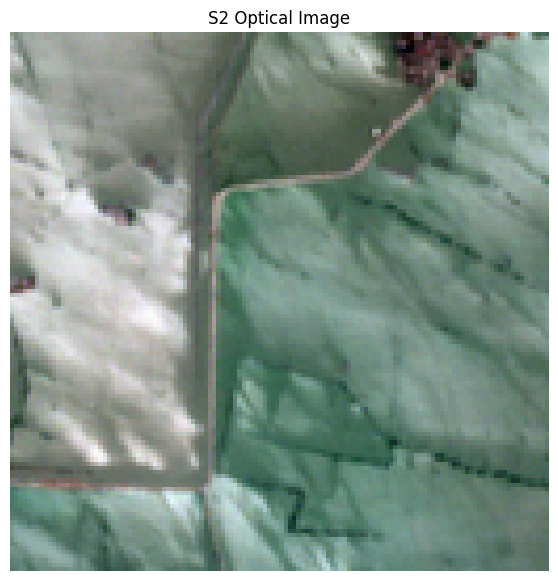

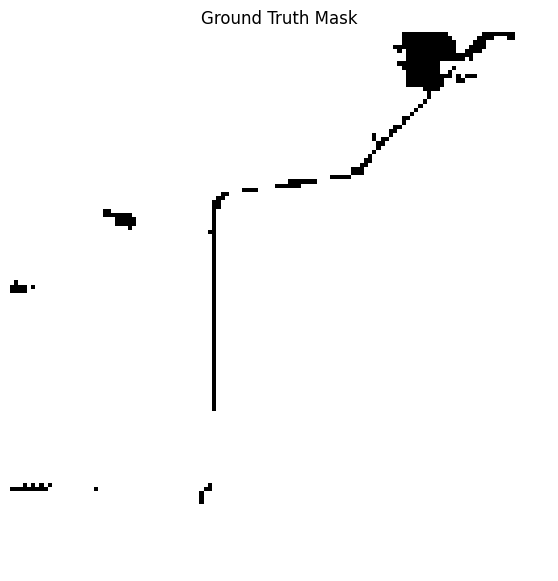

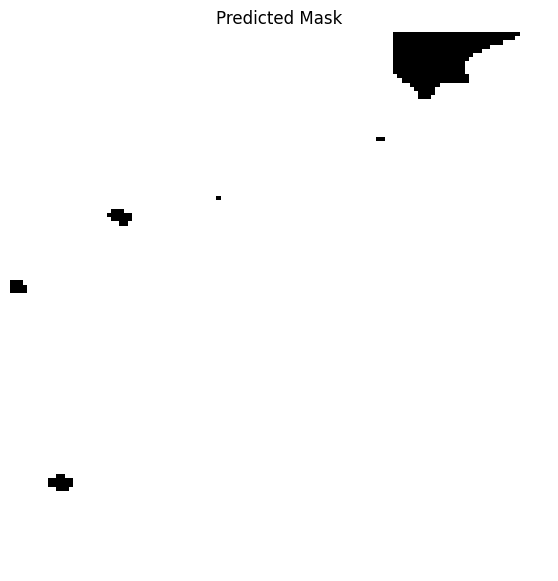

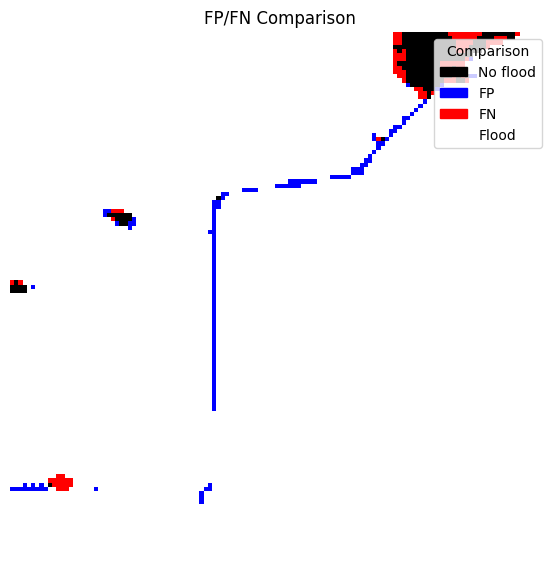

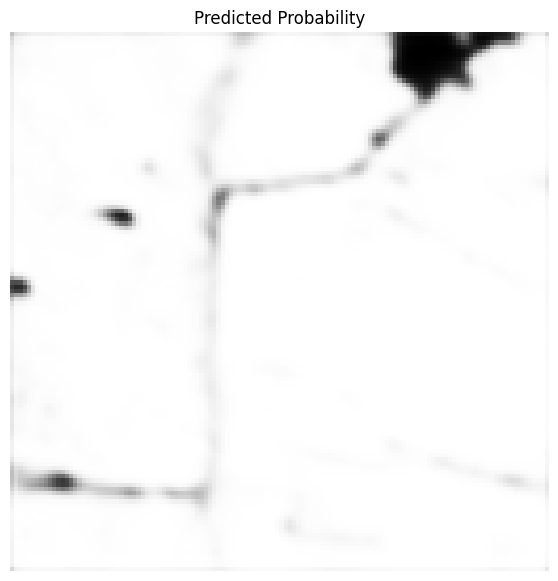

In [7]:
plot.plot_fusion_results(results)